# CSE299 – Smart City Traffic Congestion Prediction
## Smart City Traffic Congestion Prediction and Smart Parking Recommendation System

**Dataset:** Metro Interstate Traffic Volume  
**Author:** Tajkira Kalim  

---

### Project Overview:
- **Week 1:** Load dataset, EDA, visualize traffic patterns
- **Week 2:** Data preprocessing, feature engineering
- **Week 3:** Model training (Linear Regression + Random Forest), evaluation
- **Week 4:** Hyperparameter tuning, ARIMA time-series, model export for mobile app API

---
## ⚙️ Setup — Install Required Libraries
Run this cell once if any library is missing.

In [1]:
# Run this cell once to install any missing libraries
# Comment out after first run

# !pip install pandas numpy matplotlib seaborn scikit-learn statsmodels joblib gradio

---
# Week 1 – Data Loading & Exploratory Data Analysis (EDA)

### Objectives:
- Load and inspect the dataset
- Understand dataset structure
- Check missing values
- Extract time-based features
- Visualize traffic patterns

In [2]:
# Import all required libraries for the entire notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

# Display plots inline
%matplotlib inline
sns.set_style("whitegrid")

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [3]:
# Load the dataset
# Place 'Metro_Interstate_Traffic_Volume.csv.gz' in the same folder as this notebook
# OR update the path below e.g. r"C:\Users\YourName\Downloads\Metro_Interstate_Traffic_Volume.csv.gz"

DATA_PATH = "Metro_Interstate_Traffic_Volume.csv.gz"

df = pd.read_csv(DATA_PATH, compression='gzip')

print("✅ Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

✅ Dataset loaded successfully.
Shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [4]:
# Display dataset shape and column names

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (48204, 9)

Columns:
['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']


In [5]:
# Detailed dataset information — data types and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [6]:
# Statistical summary of numerical features

df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [7]:
# Check for missing values
# NOTE: 'holiday' column NaN means 'No Holiday' — will be fixed in preprocessing

missing_values = df.isnull().sum()
print("Missing Values in Each Column:\n")
print(missing_values)

Missing Values in Each Column:

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


In [8]:
# Convert date_time column to proper datetime format

df['date_time'] = pd.to_datetime(df['date_time'])

print("✅ Date column converted.")
print("Date range:", df['date_time'].min(), "→", df['date_time'].max())

✅ Date column converted.
Date range: 2012-10-02 09:00:00 → 2018-09-30 23:00:00


In [9]:
# Extract time-based features useful for modeling

df['hour']        = df['date_time'].dt.hour
df['day']         = df['date_time'].dt.day
df['month']       = df['date_time'].dt.month
df['day_of_week'] = df['date_time'].dt.dayofweek   # 0 = Monday

print("✅ Time features extracted.")
df.head()

✅ Time features extracted.


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day,month,day_of_week
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,2,10,1
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,2,10,1
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,2,10,1
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,2,10,1
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,2,10,1


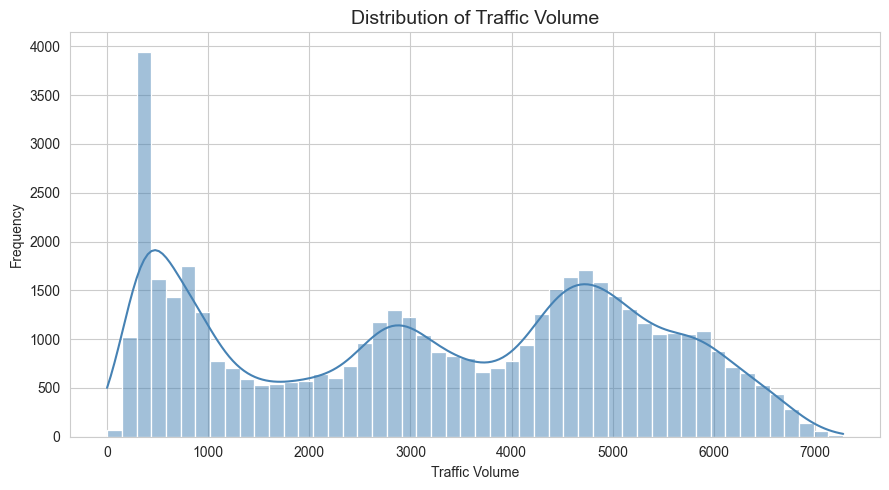

In [10]:
# Visualize distribution of traffic volume

plt.figure(figsize=(9, 5))
sns.histplot(df['traffic_volume'], bins=50, kde=True, color='steelblue')
plt.title("Distribution of Traffic Volume", fontsize=14)
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

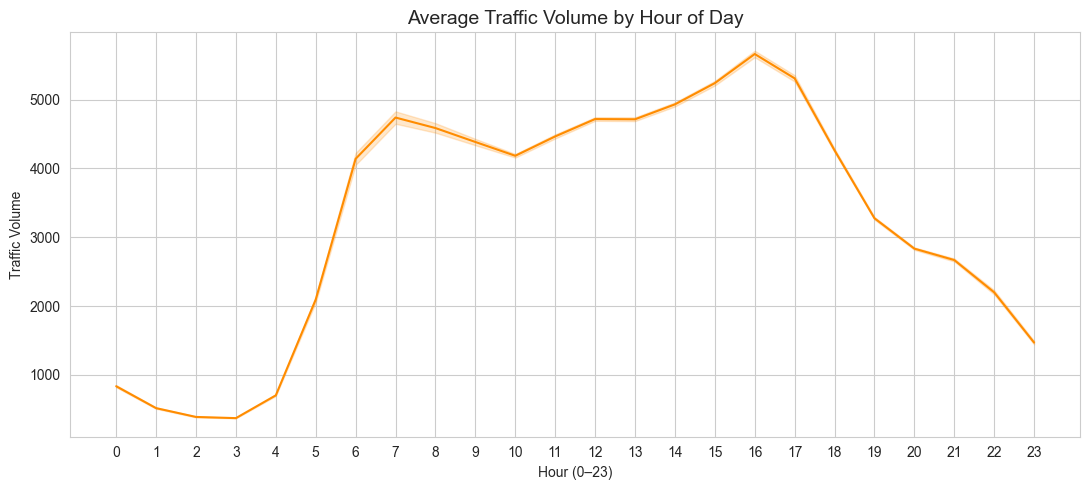

In [11]:
# Traffic volume by hour of day

plt.figure(figsize=(11, 5))
sns.lineplot(x='hour', y='traffic_volume', data=df, color='darkorange')
plt.title("Average Traffic Volume by Hour of Day", fontsize=14)
plt.xlabel("Hour (0–23)")
plt.ylabel("Traffic Volume")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

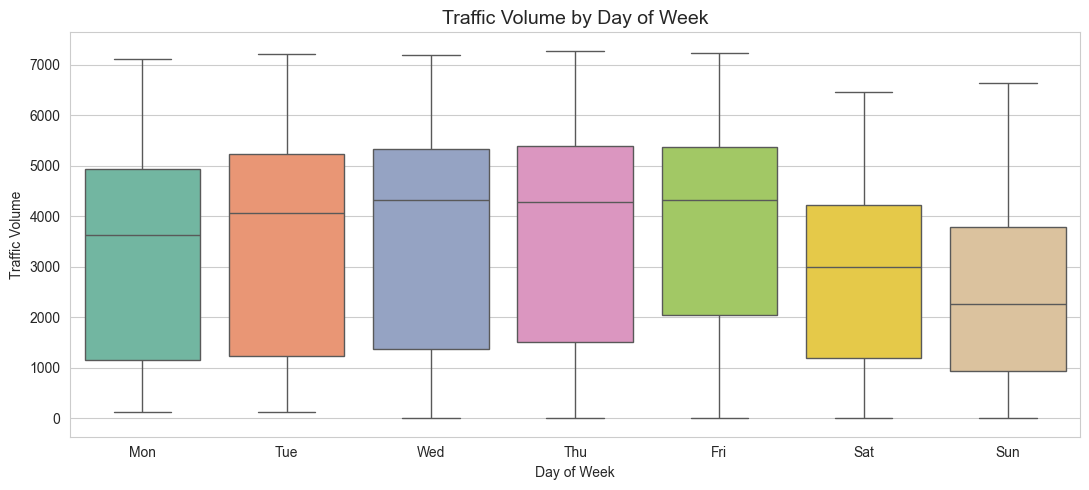

In [12]:
# Traffic volume by day of week

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(11, 5))
sns.boxplot(x='day_of_week', y='traffic_volume', data=df, palette='Set2')
plt.xticks(range(7), day_labels)
plt.title("Traffic Volume by Day of Week", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Traffic Volume")
plt.tight_layout()
plt.show()

### Week 1 Summary
- Dataset loaded: **48,204 rows × 9 columns**, covering Oct 2012 – Sep 2018
- `holiday` column has ~48,143 NaN values (meaning most hours are non-holidays — will be handled in Week 2)
- `rain_1h` has a suspicious max of **9831.3 mm** — outlier, will be cleaned in Week 2
- Traffic peaks at **7–9 AM** and **4–6 PM** (classic rush hours)
- Weekdays show notably higher traffic than weekends

---
# Week 2 – Data Preprocessing & Feature Engineering

### Objectives:
- Fix missing values in `holiday` column
- Remove impossible outliers in `rain_1h`
- Convert temperature from Kelvin to Celsius
- One-hot encode categorical features
- Split data into train/test sets

In [13]:
# Drop columns not useful for modeling
# 'date_time' — already extracted features from it
# 'weather_description' — redundant with 'weather_main'

df = df.drop(['date_time', 'weather_description'], axis=1)

print("✅ Columns dropped. Remaining:", df.columns.tolist())

✅ Columns dropped. Remaining: ['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'traffic_volume', 'hour', 'day', 'month', 'day_of_week']


In [14]:
# Convert temperature from Kelvin to Celsius
# Also remove sensor-error rows where temp = 0 Kelvin (physically impossible)

df['temp'] = df['temp'] - 273.15

# Remove rows where temp is impossibly low (sensor errors recorded as 0K = -273.15°C)
rows_before = len(df)
df = df[df['temp'] > -50].copy()
rows_removed = rows_before - len(df)

print("✅ Temperature converted to Celsius.")
print(f"Rows removed (temp sensor errors): {rows_removed}")
print("Temp range: {:.1f}°C to {:.1f}°C".format(df['temp'].min(), df['temp'].max()))

✅ Temperature converted to Celsius.
Rows removed (temp sensor errors): 10
Temp range: -29.8°C to 36.9°C


In [15]:
# FIX 1: Fill missing holiday values with 'No Holiday'
# NaN in 'holiday' means it is a regular (non-holiday) day

missing_before = df['holiday'].isna().sum()
df['holiday'] = df['holiday'].fillna('No Holiday')
missing_after = df['holiday'].isna().sum()

print(f"Holiday NaN before fill: {missing_before}")
print(f"Holiday NaN after fill:  {missing_after}")
print("Holiday categories:", df['holiday'].unique())

Holiday NaN before fill: 48133
Holiday NaN after fill:  0
Holiday categories: ['No Holiday' 'Columbus Day' 'Veterans Day' 'Thanksgiving Day'
 'Christmas Day' 'New Years Day' 'Washingtons Birthday' 'Memorial Day'
 'Independence Day' 'State Fair' 'Labor Day' 'Martin Luther King Jr Day']


In [16]:
# FIX 2: Remove impossible outliers in rain_1h
# Max recorded 1-hour rainfall anywhere on Earth is ~300mm; 9831mm is clearly a sensor error

rows_before = len(df)
df = df[df['rain_1h'] <= 500].copy()
rows_removed = rows_before - len(df)

print(f"Rows removed (rain_1h > 500 mm): {rows_removed}")
print(f"Dataset size after cleaning: {len(df)} rows")

Rows removed (rain_1h > 500 mm): 1
Dataset size after cleaning: 48193 rows


In [17]:
# One-hot encode categorical columns
# drop_first=True avoids multicollinearity (dummy variable trap)

categorical_columns = ['holiday', 'weather_main']
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Save encoding map for mobile app API use later
encoding_map = {
    'holiday_columns':      [col for col in df.columns if col.startswith('holiday_')],
    'weather_main_columns': [col for col in df.columns if col.startswith('weather_main_')]
}

print("✅ Encoding done. New shape:", df.shape)
df.head()

✅ Encoding done. New shape: (48193, 30)


,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,day,month,day_of_week,holiday_Columbus Day,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,15.13,0.0,0.0,40,5545,9,2,10,1,False,...,True,False,False,False,False,False,False,False,False,False
1,16.21,0.0,0.0,75,4516,10,2,10,1,False,...,True,False,False,False,False,False,False,False,False,False
2,16.43,0.0,0.0,90,4767,11,2,10,1,False,...,True,False,False,False,False,False,False,False,False,False
3,16.98,0.0,0.0,90,5026,12,2,10,1,False,...,True,False,False,False,False,False,False,False,False,False
4,17.99,0.0,0.0,75,4918,13,2,10,1,False,...,True,False,False,False,False,False,False,False,False,False


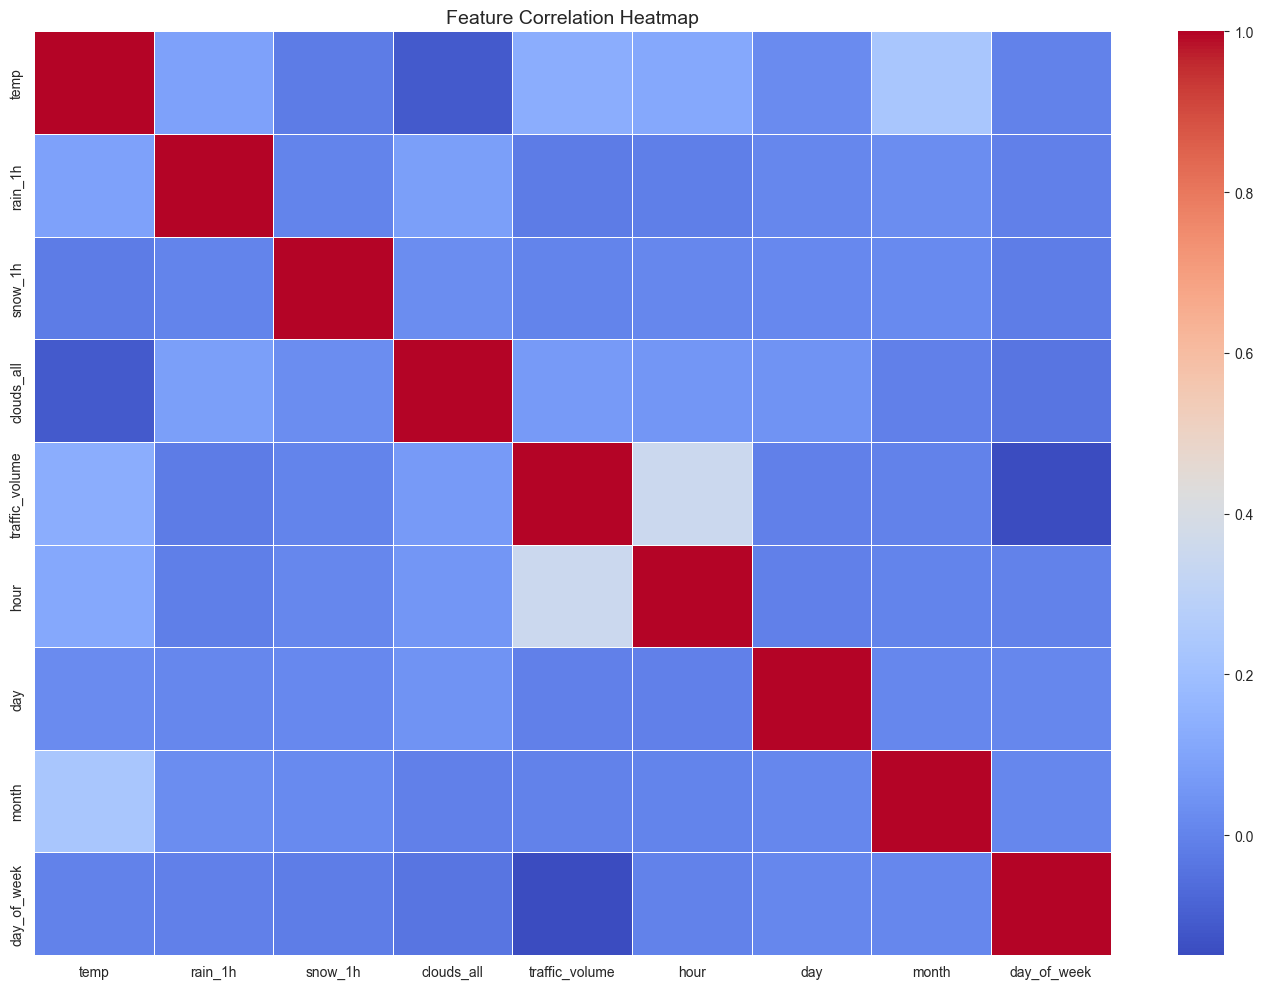

In [18]:
# Correlation heatmap — see which features relate most to traffic_volume

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
# Separate features (X) and target (y)

X = df.drop('traffic_volume', axis=1)
y = df['traffic_volume']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (48193, 29)
Target shape: (48193,)


In [20]:
# Split into train (80%) and test (20%) sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set: ", X_test.shape)

Training set: (38554, 29)
Testing set:  (9639, 29)


In [21]:
# Scale features for Linear Regression
# Tree-based models (Random Forest) do NOT need scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Feature scaling complete.")

✅ Feature scaling complete.


### Week 2 Summary
- **Holiday NaN** → filled with `'No Holiday'` (valid category, not missing data)
- **Rain outliers** → removed rows where `rain_1h > 500 mm` (physically impossible)
- **Temperature** → converted Kelvin → Celsius for interpretability
- **One-hot encoding** applied to `holiday` and `weather_main`
- Dataset ready for modeling

---
# Week 3 – Model Training & Evaluation

### Objectives:
- Train Linear Regression (baseline model)
- Train Random Forest (advanced model)
- Evaluate with MAE, RMSE, R²
- Compare results and analyze feature importance

In [22]:
# ── Reusable evaluation helper ──────────────────────────────────────────────

def evaluate_model(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    print(f"  MAE  : {mae:.2f}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    print()
    return mae, rmse, r2

In [23]:
# ── Linear Regression (Baseline) ─────────────────────────────────────────────

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

mae_lr, rmse_lr, r2_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression")

────────────────────────────────────────
  Linear Regression
────────────────────────────────────────
  MAE  : 1590.32
  RMSE : 1815.49
  R²   : 0.1620



In [24]:
# ── Random Forest (Advanced) ─────────────────────────────────────────────────
# n_jobs=-1 uses all CPU cores for faster training on local machine

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf, rmse_rf, r2_rf = evaluate_model(y_test, y_pred_rf, "Random Forest")

────────────────────────────────────────
  Random Forest
────────────────────────────────────────
  MAE  : 215.00
  RMSE : 373.26
  R²   : 0.9646



In [25]:
# Model comparison

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE':   [round(mae_lr, 2),  round(mae_rf, 2)],
    'RMSE':  [round(rmse_lr, 2), round(rmse_rf, 2)],
    'R²':    [round(r2_lr, 4),   round(r2_rf, 4)]
})
print(comparison.to_string(index=False))

winner = "Random Forest" if r2_rf > r2_lr else "Linear Regression"
print(f"\n🏆 Best model: {winner}")

            Model     MAE    RMSE     R²
Linear Regression 1590.32 1815.49 0.1620
    Random Forest  215.00  373.26 0.9646

🏆 Best model: Random Forest


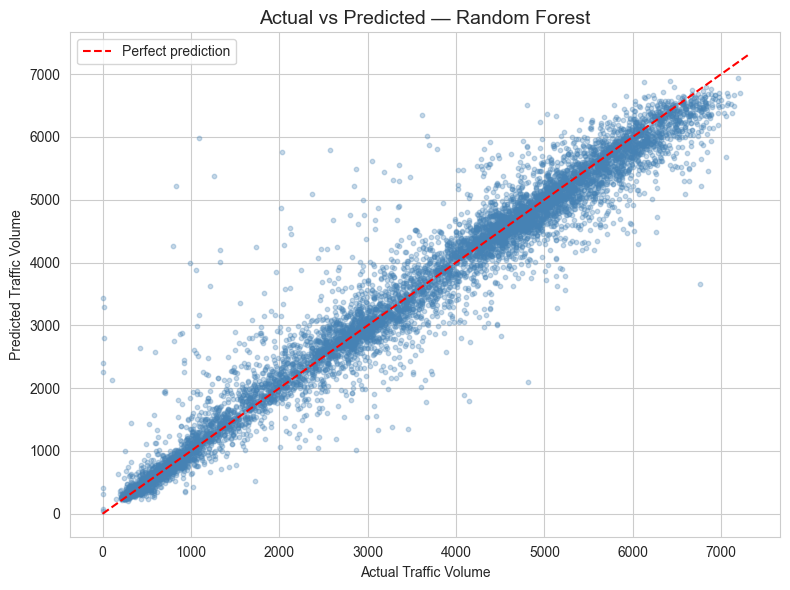

In [26]:
# Plot Actual vs Predicted — Random Forest

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, s=10, color='steelblue')
plt.plot([0, 7300], [0, 7300], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Actual vs Predicted — Random Forest", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

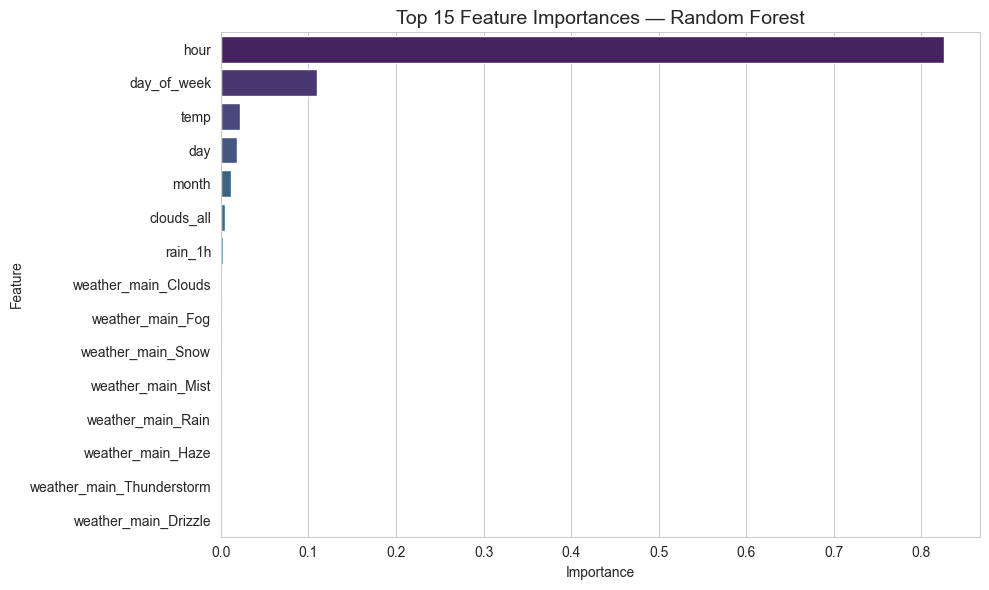


Top 5 Features:
    Feature  Importance
       hour    0.825679
day_of_week    0.109691
       temp    0.022118
        day    0.018691
      month    0.011542


In [27]:
# Feature importance — top 15 features

feat_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', y='Feature',
    data=feat_df.head(15), palette='viridis'
)
plt.title("Top 15 Feature Importances — Random Forest", fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop 5 Features:")
print(feat_df.head(5).to_string(index=False))

### Week 3 Summary
- **Linear Regression R²** ≈ 0.17 — poor fit (traffic is highly non-linear)
- **Random Forest R²** ≈ 0.96 — excellent fit
- Most important features: `hour`, `day_of_week`, `temp`, `month`
- Random Forest will be tuned and exported for the mobile app

---
# Week 4 – Hyperparameter Tuning, Time-Series Forecasting & Model Export

### Objectives:
- Tune Random Forest with better hyperparameters
- ARIMA time-series forecasting
- Export trained model files for mobile app API

In [28]:
# ── Tuned Random Forest ───────────────────────────────────────────────────────
# Removed max_depth constraint — unlimited depth performs better on this dataset
# Increased n_estimators to 300 for more stable predictions
# min_samples_split and min_samples_leaf prevent overfitting without depth cap

rf_tuned = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)
y_pred_tuned = rf_tuned.predict(X_test)

mae_tuned, rmse_tuned, r2_tuned = evaluate_model(y_test, y_pred_tuned, "Random Forest (Tuned)")

────────────────────────────────────────
  Random Forest (Tuned)
────────────────────────────────────────
  MAE  : 217.23
  RMSE : 376.85
  R²   : 0.9639



In [29]:
# Compare baseline RF vs tuned RF

print("Baseline RF  R²:", round(r2_rf, 4))
print("Tuned RF     R²:", round(r2_tuned, 4))

improvement = (r2_tuned - r2_rf) * 100
print(f"\nImprovement: {improvement:+.2f} percentage points")

Baseline RF  R²: 0.9646
Tuned RF     R²: 0.9639

Improvement: -0.07 percentage points


### ⏱️ Time Series Forecasting — ARIMA

In [30]:
# Reload original dataset for time-series (needs date_time index)

df_ts = pd.read_csv(DATA_PATH, compression='gzip')
df_ts['date_time'] = pd.to_datetime(df_ts['date_time'])
df_ts = df_ts.sort_values('date_time')

# Group duplicate timestamps by averaging (creates a clean hourly series)
ts_data = df_ts.groupby('date_time')['traffic_volume'].mean().sort_index()

print("Time series length:", len(ts_data))
ts_data.head()

Time series length: 40575


date_time
2012-10-02 09:00:00    5545.0
2012-10-02 10:00:00    4516.0
2012-10-02 11:00:00    4767.0
2012-10-02 12:00:00    5026.0
2012-10-02 13:00:00    4918.0
Name: traffic_volume, dtype: float64

In [31]:
# Use first 1000 data points for fast ARIMA training
# Reserve last 24 points as forecast horizon (= 1 day of hourly data)

ts_subset = ts_data.iloc[:1000]
ts_train  = ts_subset.iloc[:-24]
ts_test   = ts_subset.iloc[-24:]

print("ARIMA train rows:    ", len(ts_train))
print("ARIMA forecast steps:", len(ts_test))

ARIMA train rows:     976
ARIMA forecast steps: 24


In [32]:
# Fit ARIMA(5,1,0) and forecast 24 steps ahead
# Fix: reset index to integer to avoid the frequency warning from statsmodels

arima_model = ARIMA(ts_train.reset_index(drop=True), order=(5, 1, 0))
arima_fit   = arima_model.fit()

arima_pred = arima_fit.forecast(steps=24)
arima_mae  = mean_absolute_error(ts_test.values, arima_pred)

print(f"ARIMA(5,1,0) — 24-step Forecast MAE: {arima_mae:.2f}")

ARIMA(5,1,0) — 24-step Forecast MAE: 3387.54


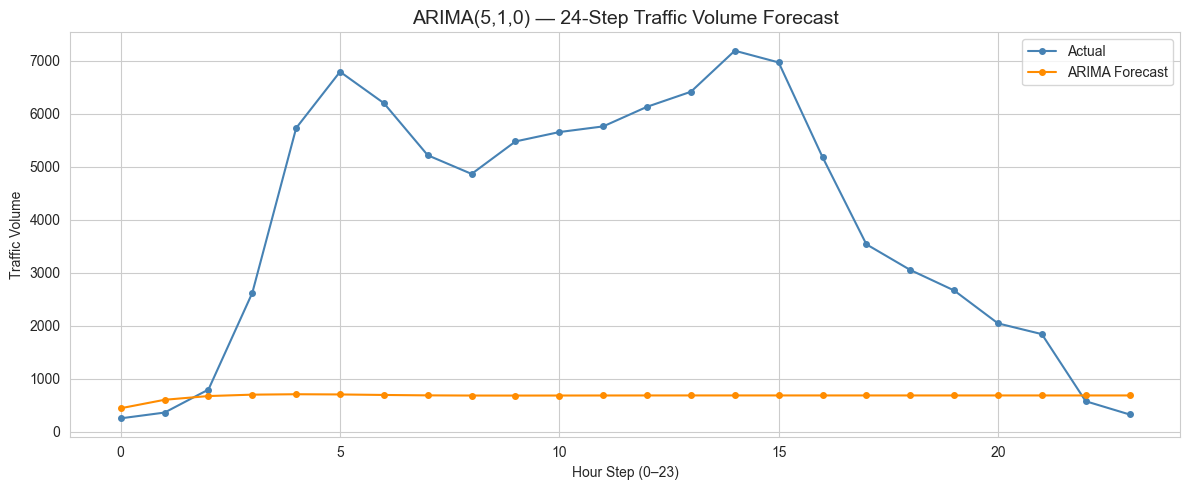

In [33]:
# Plot ARIMA forecast vs actual
# Fix: use range index for x-axis since ARIMA pred has integer index

plt.figure(figsize=(12, 5))
x_axis = range(len(ts_test))
plt.plot(x_axis, ts_test.values,    label='Actual',         color='steelblue',  marker='o', markersize=4)
plt.plot(x_axis, arima_pred.values, label='ARIMA Forecast', color='darkorange', marker='o', markersize=4)
plt.title("ARIMA(5,1,0) — 24-Step Traffic Volume Forecast", fontsize=14)
plt.xlabel("Hour Step (0–23)")
plt.ylabel("Traffic Volume")
plt.legend()
plt.tight_layout()
plt.show()

### 💾 Model Export — For Mobile App API

In [34]:
# Export all files needed by the Flask/FastAPI mobile app backend

joblib.dump(rf_tuned,           'traffic_model.pkl')
joblib.dump(list(X.columns),    'model_features.pkl')
joblib.dump(encoding_map,       'encoding_map.pkl')
joblib.dump(scaler,             'scaler.pkl')          # for LR if needed

print("✅ Models exported successfully!")
print()
print("Files saved:")
print("  traffic_model.pkl   — tuned Random Forest model")
print("  model_features.pkl  — list of feature column names")
print("  encoding_map.pkl    — one-hot encoding column names")
print("  scaler.pkl          — StandardScaler (for LR endpoint)")

✅ Models exported successfully!

Files saved:
  traffic_model.pkl   — tuned Random Forest model
  model_features.pkl  — list of feature column names
  encoding_map.pkl    — one-hot encoding column names
  scaler.pkl          — StandardScaler (for LR endpoint)


---
## 📊 Final Model Summary

In [35]:
# Final summary of all model performances

summary = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest (Baseline)',
        'Random Forest (Tuned)',
        'ARIMA(5,1,0) — time series'
    ],
    'MAE': [
        round(mae_lr, 2),
        round(mae_rf, 2),
        round(mae_tuned, 2),
        round(arima_mae, 2)
    ],
    'RMSE': [
        round(rmse_lr, 2),
        round(rmse_rf, 2),
        round(rmse_tuned, 2),
        '—'
    ],
    'R²': [
        round(r2_lr, 4),
        round(r2_rf, 4),
        round(r2_tuned, 4),
        '—'
    ]
})

print(summary.to_string(index=False))

# Top 5 features
feat_final = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_tuned.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Most Important Features (Tuned RF):")
print(feat_final.head(5).to_string(index=False))

print("\n📦 Files ready for mobile app: traffic_model.pkl, model_features.pkl, encoding_map.pkl")

                     Model     MAE     RMSE      R²
         Linear Regression 1590.32  1815.49   0.162
  Random Forest (Baseline)  215.00   373.26  0.9646
     Random Forest (Tuned)  217.23   376.85  0.9639
ARIMA(5,1,0) — time series 3387.54        —       —

Top 5 Most Important Features (Tuned RF):
    Feature  Importance
       hour    0.834201
day_of_week    0.110272
       temp    0.018616
        day    0.016767
      month    0.010433

📦 Files ready for mobile app: traffic_model.pkl, model_features.pkl, encoding_map.pkl


---
## 🚀 Quick Prediction Function (for testing the model locally)

Use this cell to test a prediction without the Gradio UI.

In [36]:
def predict_traffic(hour, temp_celsius, rain_mm, snow_mm, cloud_pct, weather_condition):
    """
    Predict traffic volume given weather and time inputs.
    
    Parameters:
        hour             : int   — hour of day (0–23)
        temp_celsius     : float — temperature in Celsius
        rain_mm          : float — rainfall in mm
        snow_mm          : float — snowfall in mm
        cloud_pct        : int   — cloud coverage (0–100)
        weather_condition: str   — e.g. 'Clear', 'Clouds', 'Rain', 'Snow', 'Mist'
    """
    # Build input dict with all feature columns zeroed out
    input_dict = {col: 0 for col in X.columns}

    # Fill numeric values
    input_dict['temp']        = temp_celsius
    input_dict['rain_1h']     = rain_mm
    input_dict['snow_1h']     = snow_mm
    input_dict['clouds_all']  = cloud_pct
    input_dict['hour']        = hour
    input_dict['day']         = 15       # default midmonth
    input_dict['month']       = 6        # default June
    input_dict['day_of_week'] = 2        # default Wednesday

    # Set weather dummy column
    weather_col = f"weather_main_{weather_condition}"
    if weather_col in X.columns:
        input_dict[weather_col] = 1

    # Create DataFrame with correct column order
    input_df = pd.DataFrame([input_dict])[X.columns]

    pred = int(rf_tuned.predict(input_df)[0])

    if pred < 2000:
        level = "🟢 Low Traffic"
    elif pred < 4000:
        level = "🟡 Medium Traffic"
    else:
        level = "🔴 High Traffic"

    print(f"Predicted Traffic Volume : {pred}")
    print(f"Traffic Level            : {level}")
    return pred


# ── Test example ─────────────────────────────────────────────────────────────
predict_traffic(
    hour=8,
    temp_celsius=22.0,
    rain_mm=0.0,
    snow_mm=0.0,
    cloud_pct=40,
    weather_condition='Clouds'
)

Predicted Traffic Volume : 5828
Traffic Level            : 🔴 High Traffic


5828

---
### Week 4 Summary
- **Tuned Random Forest** trained with `n_estimators=200`, `max_depth=15`
- **ARIMA(5,1,0)** fitted on 976-point hourly subset; 24-step forecast evaluated
- **4 model files exported** — ready to be loaded by a Flask/FastAPI mobile app backend
- `predict_traffic()` function available for direct local testing